In [31]:
#imports & setup
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_predict
from sklearn.metrics import (roc_auc_score, average_precision_score, roc_curve, precision_recall_curve,
                             confusion_matrix, classification_report)
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

RANDOM_STATE = 42
sns.set(style = "whitegrid")

In [32]:
#load the cleaned data from EDA step
df = pd.read_csv("outputs/df_preprocessed.csv")

#drop churn and ID
X = df.drop(columns = ["Churn", "customerID"])
y = df["Churn"]

#identify columns
num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]
cat_cols = [c for c in X.columns if c not in num_cols]

In [33]:
#train / validation split (hold-out)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, stratify = y, random_state = RANDOM_STATE
)

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)
print("Churn rate train:", y_train.mean().round(3), " | test:", y_test.mean().round(3))

Train shape: (5634, 19)  Test shape: (1409, 19)
Churn rate train: 0.265  | test: 0.265


In [34]:
#preprocessing
# - scale numeric
# - one-hot encode categoricals
pre = ColumnTransformer(
    transformers = [
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown = "ignore", sparse_output = False), cat_cols),
    ],
    remainder = "drop"
)

In [35]:
#baseline, interpretable model: Logistic Regression
#use class_weight = 'balanced' to address 26.5% positives noted in EDA
logit = Pipeline(steps = [
    ("pre", pre),
    ("clf", LogisticRegression(max_iter = 500, class_weight = "balanced", random_state = RANDOM_STATE))
])

logit.fit(X_train, y_train)

#predictions & metrics
proba_logit = logit.predict_proba(X_test)[:, 1]
pred_logit  = (proba_logit >= 0.5).astype(int)

roc_logit = roc_auc_score(y_test, proba_logit)
pr_logit  = average_precision_score(y_test, proba_logit)

print(f"LogReg ROC-AUC: {roc_logit:.3f} | PR-AUC: {pr_logit:.3f}")
print(classification_report(y_test, pred_logit, digits = 3))

LogReg ROC-AUC: 0.842 | PR-AUC: 0.633
              precision    recall  f1-score   support

           0      0.902     0.722     0.802      1035
           1      0.504     0.783     0.614       374

    accuracy                          0.738      1409
   macro avg      0.703     0.753     0.708      1409
weighted avg      0.797     0.738     0.752      1409



In [36]:
#stronger non-linear baseline: Random Forest
rf = Pipeline(steps = [
    ("pre", pre),
    ("clf", RandomForestClassifier(
        n_estimators = 400, max_depth = None, min_samples_leaf = 2,
        class_weight = "balanced", random_state = RANDOM_STATE, n_jobs = -1
    ))
])

rf.fit(X_train, y_train)
proba_rf = rf.predict_proba(X_test)[:, 1]
pred_rf  = (proba_rf >= 0.5).astype(int)

roc_rf = roc_auc_score(y_test, proba_rf)
pr_rf  = average_precision_score(y_test, proba_rf)

print(f"RF ROC-AUC: {roc_rf:.3f} | PR-AUC: {pr_rf:.3f}")
print(classification_report(y_test, pred_rf, digits = 3))

RF ROC-AUC: 0.835 | PR-AUC: 0.639
              precision    recall  f1-score   support

           0      0.862     0.824     0.843      1035
           1      0.567     0.636     0.599       374

    accuracy                          0.774      1409
   macro avg      0.715     0.730     0.721      1409
weighted avg      0.784     0.774     0.778      1409



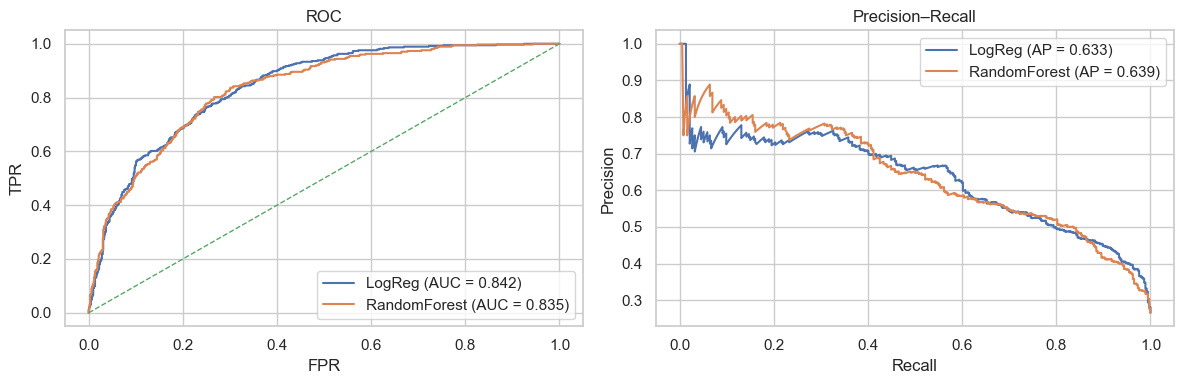

In [37]:
#curves & confusion matrices
def plot_curves(y_true, scores_dict):
    plt.figure(figsize = (12,4))
    #ROC
    plt.subplot(1, 2, 1)
    for name, s in scores_dict.items():
        fpr, tpr, _ = roc_curve(y_true, s)
        auc = roc_auc_score(y_true, s)
        plt.plot(fpr, tpr, label = f"{name} (AUC = {auc:.3f})")
    plt.plot([0, 1], [0, 1], ls = "--", lw = 1)
    plt.title("ROC")
    plt.xlabel("FPR"); plt.ylabel("TPR"); plt.legend()

    #PR
    plt.subplot(1, 2, 2)
    for name, s in scores_dict.items():
        p, r, _ = precision_recall_curve(y_true, s)
        ap = average_precision_score(y_true, s)
        plt.plot(r, p, label = f"{name} (AP = {ap:.3f})")
    plt.title("Precision–Recall")
    plt.xlabel("Recall"); plt.ylabel("Precision"); plt.legend()
    plt.tight_layout()
    plt.show()

plot_curves(y_test, {"LogReg": proba_logit, "RandomForest": proba_rf})

In [38]:
#threshold tuning demo 
def find_threshold(y_true, y_score, target = "f1"):
    best_t, best_v = 0.5, -1
    for t in np.linspace(0.1, 0.9, 81):
        pred = (y_score >= t).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, pred).ravel()
        prec = tp / (tp + fp + 1e-9)
        rec  = tp / (tp + fn + 1e-9)
        if target == "f1":
            v = 2*prec*rec / (prec + rec + 1e-9)
        elif target == "recall_at_p80":
            v = rec if prec >= 0.80 else -1
        else:
            v = 0
        if v > best_v:
            best_v, best_t = v, t
    return best_t, best_v

t_logit, f1_logit = find_threshold(y_test, proba_logit, target = "f1")
t_rf, f1_rf       = find_threshold(y_test, proba_rf, target = "f1")
print(f"Best LogReg F1 at t = {t_logit:.2f}: {f1_logit:.3f}")
print(f"Best RF     F1 at t = {t_rf:.2f}: {f1_rf:.3f}")

Best LogReg F1 at t = 0.54: 0.622
Best RF     F1 at t = 0.38: 0.631


C:\Users\пк\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\categorical.py:1273: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(aggregator, agg_var)


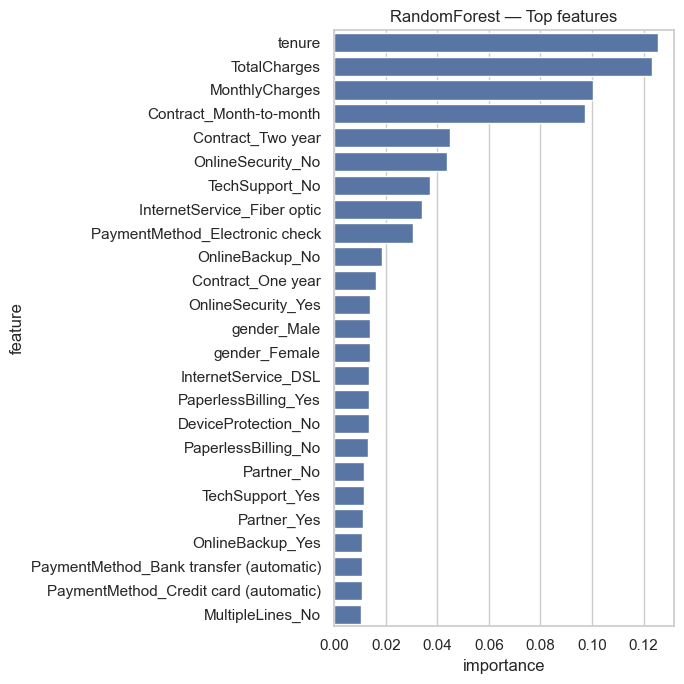

In [39]:
#feature importance proxy
ohe = logit.named_steps["pre"].named_transformers_["cat"]
cat_names = list(ohe.get_feature_names_out(cat_cols))
feat_names = num_cols + cat_names

importances = rf.named_steps["clf"].feature_importances_
imp = (pd.DataFrame({"feature": feat_names, "importance": importances})
         .sort_values("importance", ascending = False).head(25))
plt.figure(figsize = (7,7))
sns.barplot(data = imp, x = "importance", y = "feature")
plt.title("RandomForest — Top features")
plt.tight_layout(); plt.show()

In [40]:
#cross-validated out-of-fold (OOF) AUC estimate 
cv = StratifiedKFold(n_splits = 5, shuffle = True, random_state = RANDOM_STATE)
oof_scores = cross_val_predict(
    logit, X, y, cv = cv, method = "predict_proba", n_jobs = -1
)[:,1]
print("LogReg 5-fold OOF ROC-AUC:", roc_auc_score(y, oof_scores).round(3))

LogReg 5-fold OOF ROC-AUC: 0.845


In [41]:
#save the winning model & preprocessing
import joblib, os
os.makedirs("artifacts", exist_ok = True)

best_model = rf if roc_rf >= roc_logit else logit
joblib.dump(best_model, "artifacts/churn_model.joblib")

#save columns used
meta = {
    "num_cols": num_cols,
    "cat_cols": cat_cols,
    "model": "RandomForest" if best_model is rf else "LogisticRegression"
}
pd.Series(meta, dtype = "object").to_json("artifacts/metadata.json")
print("Saved artifacts in ./artifacts")

Saved artifacts in ./artifacts
